# Monitoring CatBoost v2

Модель и порог уже зафиксированы на апреле. Май–август — новый production-период, который не использовался ни для обучения, ни для выбора параметров или threshold.

## 1. Загружаем новые бронирования

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.inference import CancellationPredictor

production = pd.read_parquet(
    "../data/processed/production.parquet"
)

production["booking_date"] = pd.to_datetime(
    production["booking_date"]
)

production.shape

(6579, 38)

В реальной работе сразу после бронирования target неизвестен. Поэтому сначала убираю его и смотрю только на прогнозы модели.

In [2]:
production_labels = production["is_canceled"].copy()
production_live = production.drop(columns="is_canceled")

predictor = CancellationPredictor()
predictions = predictor.predict_batch(production_live)

predictions.head()

,prediction,cancellation_probability,model_version
0,0,0.184159,v2
1,0,0.129183,v2
2,0,0.066737,v2
3,0,0.066737,v2
4,0,0.066737,v2


## 2. Monitoring без фактических ответов

In [3]:
pd.Series({
    "rows": len(predictions),
    "mean_probability": predictions[
        "cancellation_probability"
    ].mean(),
    "predicted_cancellation_rate": predictions[
        "prediction"
    ].mean(),
    "threshold": predictor.threshold,
}).round(4)

rows                           6579.0000
mean_probability                  0.2198
predicted_cancellation_rate       0.2032
threshold                         0.4057
dtype: float64

### Как меняются прогнозы по месяцам

In [4]:
monitoring = production[["booking_date"]].join(
    predictions
)

monthly_predictions = (
    monitoring
    .set_index("booking_date")
    .resample("MS")
    .agg(
        bookings=("prediction", "size"),
        mean_probability=(
            "cancellation_probability",
            "mean"
        ),
        predicted_rate=("prediction", "mean"),
    )
)

monthly_predictions.round(4)

,bookings,mean_probability,predicted_rate
booking_date,,,
2017-05-01,2883,0.2405,0.2307
2017-06-01,1626,0.2313,0.2239
2017-07-01,1340,0.2071,0.1888
2017-08-01,730,0.1359,0.0753


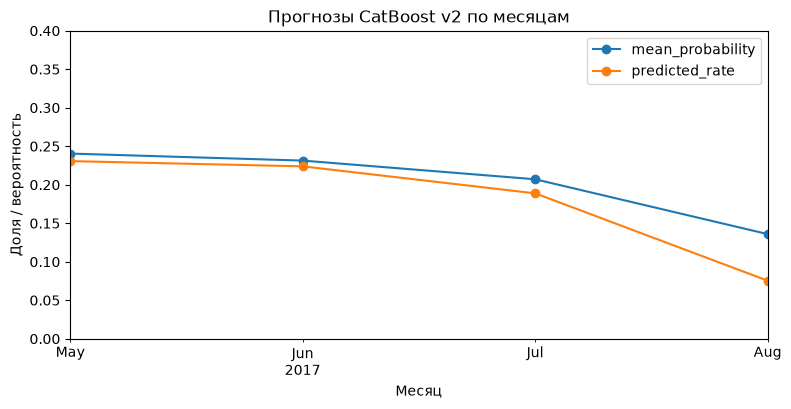

In [5]:
monthly_predictions[[
    "mean_probability",
    "predicted_rate"
]].plot(
    marker="o",
    figsize=(9, 4)
)

plt.title("Прогнозы CatBoost v2 по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доля / вероятность")
plt.ylim(0, 0.4)
plt.show()

По одним прогнозам нельзя понять качество модели, но можно увидеть резкое изменение их уровня. Здесь сильного скачка нет: средняя вероятность и доля срабатываний меняются постепенно.

## 3. Проверяем качество после появления labels

In [6]:
production_proba = predictions[
    "cancellation_probability"
]

production_pred = predictions[
    "prediction"
]

production_metrics = pd.Series({
    "precision": precision_score(
        production_labels,
        production_pred
    ),
    "recall": recall_score(
        production_labels,
        production_pred
    ),
    "f1": f1_score(
        production_labels,
        production_pred
    ),
    "roc_auc": roc_auc_score(
        production_labels,
        production_proba
    ),
    "pr_auc": average_precision_score(
        production_labels,
        production_proba
    ),
})

production_metrics.round(4)

precision    0.6739
recall       0.5088
f1           0.5798
roc_auc      0.8596
pr_auc       0.6852
dtype: float64

### Качество по месяцам

In [7]:
quality_data = production[[
    "booking_date",
    "is_canceled"
]].join(predictions)

monthly_quality = []

for month, data in quality_data.groupby(
    quality_data["booking_date"].dt.to_period("M")
):
    monthly_quality.append({
        "month": str(month),
        "rows": len(data),
        "actual_rate": data["is_canceled"].mean(),
        "predicted_rate": data["prediction"].mean(),
        "precision": precision_score(
            data["is_canceled"],
            data["prediction"]
        ),
        "recall": recall_score(
            data["is_canceled"],
            data["prediction"]
        ),
    })

monthly_quality = pd.DataFrame(
    monthly_quality
).set_index("month")

monthly_quality.round(4)

,rows,actual_rate,predicted_rate,precision,recall
month,,,,,
2017-05,2883,0.2896,0.2307,0.6752,0.5377
2017-06,1626,0.2817,0.2239,0.6786,0.5393
2017-07,1340,0.2701,0.1888,0.6640,0.4641
2017-08,730,0.1589,0.0753,0.6727,0.3190


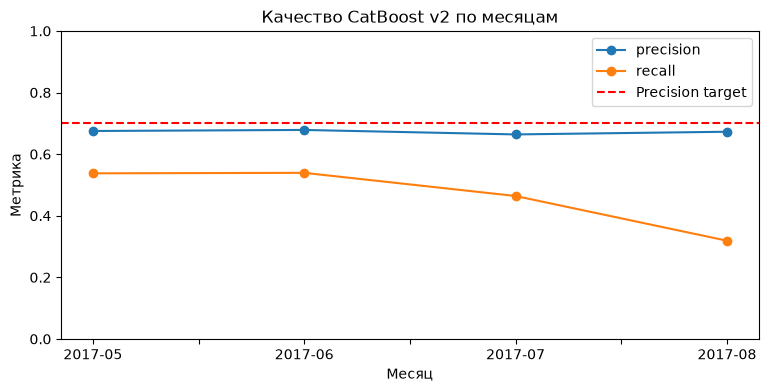

In [8]:
monthly_quality[[
    "precision",
    "recall"
]].plot(
    marker="o",
    figsize=(9, 4)
)

plt.axhline(
    0.70,
    color="red",
    linestyle="--",
    label="Precision target"
)

plt.title("Качество CatBoost v2 по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Метрика")
plt.ylim(0, 1)
plt.legend()
plt.show()

## 4. Сравниваем апрель и production

In [9]:
test = pd.read_parquet(
    "../data/processed/test.parquet"
)

april = test[
    pd.to_datetime(test["booking_date"]).dt.month == 4
]

drift = pd.DataFrame({
    "april": {
        "cancellation_rate": april["is_canceled"].mean(),
        "lead_time_median": april["lead_time"].median(),
        "adr_median": april["adr"].median(),
        "non_refund_share": (
            april["deposit_type"] == "Non Refund"
        ).mean(),
    },
    "may_august": {
        "cancellation_rate": production["is_canceled"].mean(),
        "lead_time_median": production["lead_time"].median(),
        "adr_median": production["adr"].median(),
        "non_refund_share": (
            production["deposit_type"] == "Non Refund"
        ).mean(),
    },
})

drift.round(4)

,april,may_august
cancellation_rate,0.3114,0.2692
lead_time_median,31.0000,17.0000
adr_median,133.4050,144.0000
non_refund_share,0.0139,0.0073


## Вывод

На независимом периоде май–август CatBoost v2 получила `ROC-AUC` около 0.86 и `PR-AUC` около 0.69. `Precision` снизился примерно до 0.67, поэтому бизнес-условие 0.70 снова не выполняется. `Recall` составил около 0.51 и особенно просел в августе.

Это честный результат production monitoring, а не повод подобрать новый threshold на тех же данных. Модель v2 оставляю зафиксированной, а следующим шагом должен быть новый цикл анализа: накопить свежие labels, проверить drift и только после этого решать, нужно ли переобучение.